# 02 – Prototype Autoencoder for AU Mic Spectra

In this notebook, I begin building and testing a convolutional autoencoder for the VIS_A spectra of AU Microscopii. Inspired by Mas-Buitrago et al. (2024), I aim to learn latent representations that capture variability across observations of a single star.

I will:
- Load and normalize the spectra from a selected spectral order.
- Define and train a 1D convolutional autoencoder.
- Visualize reconstructions and latent encodings.


In [17]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from astropy.io import fits
from tensorflow.keras.models import Model

This we need for analyzing the important orders in more detail:

In [18]:
selected_orders = [25, 46, 47]
latent_dir = "../outputs/latent"
os.makedirs(latent_dir, exist_ok=True)

Loading the data:

In [19]:
fits_root = "../../aumicAE1"

with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

print(f"Loaded {len(vis_a_files)} resolved FITS file paths.")

Loaded 95 resolved FITS file paths.


In [20]:
with fits.open(vis_a_files[0]) as hdul:
    hdul.info()

Filename: ../../aumicAE1/data/AUMic/CARVIS/car-20190714T01h22m54s-sci-gtoc-vis_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     465   ()      
  1  SPEC          1 ImageHDU         8   (4096, 61)   float32   
  2  CONT          1 ImageHDU         8   (4096, 61)   float32   
  3  SIG           1 ImageHDU         8   (4096, 61)   float32   
  4  WAVE          1 ImageHDU         8   (4096, 61)   float64   


In [21]:
with fits.open(vis_a_files[0]) as hdul:
    print(hdul["SPEC"].data.shape)
    print(hdul["SPEC"].data[:, 30].shape)
    print(hdul["SPEC"].data[30, :].shape)

(61, 4096)
(61,)
(4096,)


## Select and Normalize One Spectral Order

For this prototype, I will work with spectral order 30. I normalize each spectrum by its continuum and clip extreme values.

In [22]:
def load_order_normalized(file_path, order_idx=30):
    with fits.open(file_path) as hdul:
        spec = hdul["SPEC"].data  
        cont = hdul["CONT"].data 

        flux = spec[order_idx, :]
        continuum = cont[order_idx, :]

        continuum = np.where(np.isfinite(continuum) & (continuum > 1e-3), continuum, 1.0)

        norm_flux = flux / continuum
        norm_flux = np.nan_to_num(norm_flux, nan=0.0, posinf=5.0, neginf=0.0)
        norm_flux = np.clip(norm_flux, 0.0, 5.0)

        return norm_flux.astype(np.float32)

## Prepare Input for Autoencoder

I reshape the data into tensors suitable for a 1D convolutional network.


In [23]:
spectra = [load_order_normalized(f) for f in vis_a_files]
spectra = np.stack(spectra)
X = spectra[..., np.newaxis]

print("Min:", np.min(X))
print("Max:", np.max(X))
print("Any NaNs?", np.isnan(X).any())
print("Any Infs?", np.isinf(X).any())

Min: 0.0
Max: 0.299978
Any NaNs? False
Any Infs? False


Save the preprocessed data for later use:

In [24]:
os.makedirs("../outputs/preprocessed", exist_ok=True)
np.save("../outputs/preprocessed/X_order30.npy", X)
print("Saved preprocessed spectra to ../outputs/preprocessed/X_order30.npy")

Saved preprocessed spectra to ../outputs/preprocessed/X_order30.npy


## Define the Autoencoder Architecture

I use a simple 1D convolutional autoencoder with a bottleneck latent layer. This will be refined in later versions.

In [25]:
def build_autoencoder(input_shape, latent_dim=8):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, 5, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(16, 5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Flatten()(x)
    encoded = layers.Dense(latent_dim, name="latent")(x)

    x = layers.Dense((input_shape[0] // 4) * 16)(encoded)
    x = layers.Reshape((input_shape[0] // 4, 16))(x)

    x = layers.Conv1DTranspose(16, 5, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1DTranspose(32, 5, activation="relu", padding="same")(x)
    x = layers.UpSampling1D(2)(x)
    outputs = layers.Conv1D(1, 3, activation="linear", padding="same")(x)

    return models.Model(inputs, outputs)

autoencoder = build_autoencoder((4096, 1))
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

2025-04-14 17:42:08.612489: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4096, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4096, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2048, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2048, 16)       │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │       131,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 1024, 16)       │         1,296 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 2048, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 2048, 32)       │         2,592 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 4096, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4096, 1)        │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,289 (1.09 MB)

 Trainable params: 285,289 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Autoencoder

I train for a small number of epochs to check if the model learns a rough reconstruction.

In [26]:
history = autoencoder.fit(X, X, epochs=20, batch_size=8, validation_split=0.1)

Epoch 1/20
 5/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0068

2025-04-14 17:42:09.943922: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0059 - val_loss: 8.6082e-04
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0013 - val_loss: 4.5608e-04
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5.2511e-04 - val_loss: 2.2221e-04
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.8810e-04 - val_loss: 1.3438e-04
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2877e-04 - val_loss: 1.3476e-04
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0765e-04 - val_loss: 1.0338e-04
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0230e-04 - val_loss: 1.1777e-04
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0040e-04 - val_loss: 9.7252e-05
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8.9417e-05 - val_loss: 1.0181e-04
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8.5717e-05 - val_loss: 1.0482e-04
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.8102e-05 - val_loss: 1.072

## Visualize Reconstructions

Now I compare original and reconstructed spectra for a few examples.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


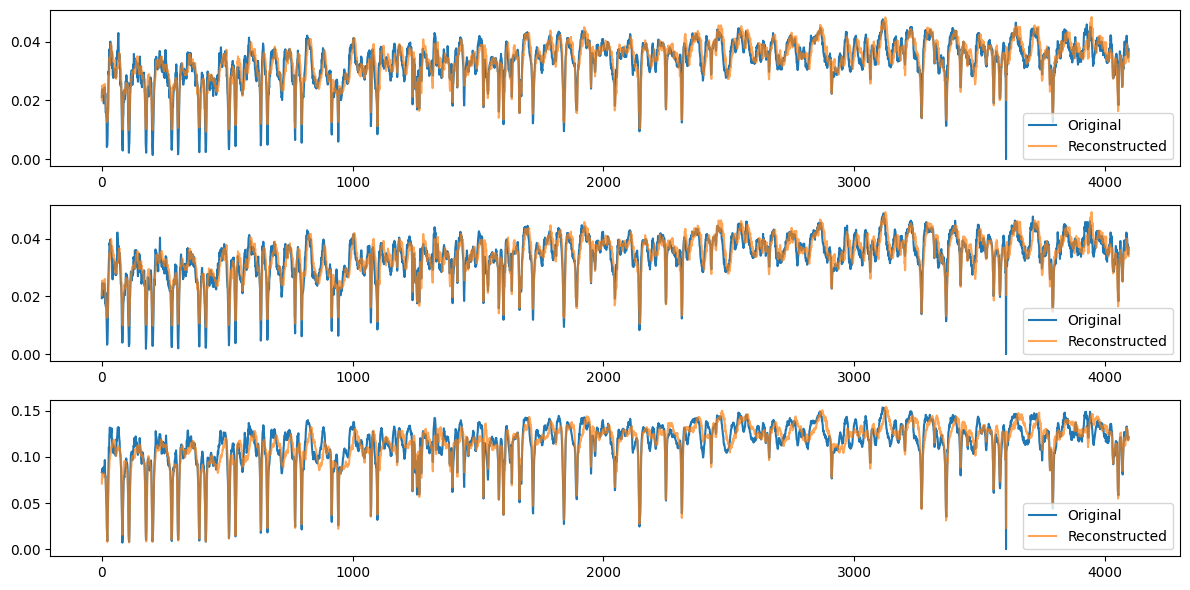

In [27]:
os.makedirs("../outputs/plots", exist_ok=True)

recon = autoencoder.predict(X)

n = 3
plt.figure(figsize=(12, 6))
for i in range(n):
    plt.subplot(n, 1, i + 1)
    plt.plot(X[i].squeeze(), label="Original")
    plt.plot(recon[i].squeeze(), label="Reconstructed", alpha=0.7)
    plt.legend()

plt.tight_layout()
plt.savefig("../outputs/plots/reconstruction_examples.png", dpi=150)
plt.show()

The plot shows that the autoencoder successfully reconstructs the overall shape and absorption features of the stellar spectra. While the reconstructed spectra closely follow the original ones, some fine details—especially sharp absorption lines—are slightly smoothed out. This indicates that the model has learned a good low-dimensional representation of the data, capturing the global spectral structure, but may still underfit high-frequency variations.

## Extract Latent Representations

I extract the compressed encoding of each spectrum from the bottleneck layer.


In [28]:
encoder = models.Model(autoencoder.input, autoencoder.get_layer("latent").output)
Z = encoder.predict(X)
print("Latent space shape:", Z.shape)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Latent space shape: (95, 8)


So, we passed 101 spectra (shape: (101, 4096, 1)) into the encoder part of your autoencoder, where each was compressed into a latent vector of 8 values. Thus, the encoded output has shape (101 samples, 8 features).

##### Saving the latent vectors for this order (30):

In [29]:
os.makedirs("../outputs/latent", exist_ok=True)
np.save("../outputs/latent/latent_vectors_order30.npy", Z)
print("Saved latent vectors to ../outputs/latent/latent_vectors_order30.npy")

Saved latent vectors to ../outputs/latent/latent_vectors_order30.npy


## Extract Latent Representations for Selected Orders

To understand how the autoencoder behaves on physically relevant spectral regions, I extract latent representations for spectral orders 25, 46, and 47. These regions include activity-sensitive lines like Hα and the Ca II infrared triplet.

In [30]:
selected_orders = [25, 46, 47]
latent_dir = "../outputs/latent"
os.makedirs(latent_dir, exist_ok=True)

def build_autoencoder(input_shape=(4096, 1), latent_dim=8):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(16, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2, padding='same')(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2, padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name="latent")(x)
    
    x = layers.Dense(1024)(latent)
    x = layers.Reshape((1024, 1))(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    decoded = layers.Conv1D(1, 3, activation='sigmoid', padding='same')(x)

    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
    return autoencoder

for order in selected_orders:
    print(f"Processing Order {order}...")

    def load_order_normalized(file_path, order_idx):
        with fits.open(file_path) as hdul:
            spec = hdul["SPEC"].data 
            cont = hdul["CONT"].data

            flux = spec[order_idx, :]
            continuum = cont[order_idx, :]

            continuum = np.where(np.isfinite(continuum) & (continuum > 1e-3), continuum, 1.0)

            norm_flux = flux / continuum
            norm_flux = np.nan_to_num(norm_flux, nan=0.0, posinf=5.0, neginf=0.0)
            norm_flux = np.clip(norm_flux, 0.0, 5.0)

            return norm_flux.astype(np.float32)

    spectra = [load_order_normalized(f, order) for f in vis_a_files]
    spectra = np.stack(spectra)
    X = spectra[..., np.newaxis]

    print("Checking input:", np.isnan(X).any(), np.isinf(X).any())
    print(f"Order {order} – spectra shape: {spectra.shape}, input shape: {X.shape}")

    # Build and train autoencoder
    autoencoder = build_autoencoder(input_shape=(4096, 1), latent_dim=8)
    history = autoencoder.fit(X, X, epochs=20, batch_size=8, validation_split=0.1, verbose=1)

    # Extract latent vectors
    encoder = Model(autoencoder.input, autoencoder.get_layer("latent").output)
    Z = encoder.predict(X)
    print("Latent shape:", Z.shape)

    np.save(os.path.join(latent_dir, f"latent_vectors_order{order}.npy"), Z)

Processing Order 25...
Checking input: False False
Order 25 – spectra shape: (95, 4096), input shape: (95, 4096, 1)
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1461 - val_loss: 0.1208
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1466 - val_loss: 0.1141
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1293 - val_loss: 0.1064
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1230 - val_loss: 0.0973
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1120 - val_loss: 0.0862
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0900 - val_loss: 0.0353
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0252 - val_loss: 0.0188
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0158 - val_loss: 0.0193
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0136 - val_loss: 0.0072
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0069 - val_loss: 0.0035
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━

## Next Steps

- Visualize the latent space over time
- Check correlations with known activity (e.g., flares, Hα lines)
- Compare latent dynamics with PCA
- Train with different orders or stacked multi-order inputs

→ Go to: `03_latent_analysis.ipynb`